### IT Service Task 

### Q.1 Import datasets and clean nulls/duplicates; format date fields.


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\HP\Desktop\New folder (2)\IT Services Task Sheet\IT Services\customers-10000.csv")

df.drop_duplicates(inplace=True)
df.fillna("", inplace=True)

df['Subscription Date'] = pd.to_datetime(df['Subscription Date'], dayfirst=True)

In [3]:
total_emp = df['Customer Id'].nunique()
print(total_emp)

10000


### Q.2 Define relationships among Employees, Projects, and Timesheets tables.


In [6]:
import pandas as pd

employees = pd.DataFrame({'EmployeeID':[1,2,3]})
projects = pd.DataFrame({'ProjectID':[101,102],
                         'EmployeeID':[1,2]})
timesheets = pd.DataFrame({'TimesheetID':[1,2],
                           'ProjectID':[101,102]})

emp_proj = pd.merge(employees, projects, on='EmployeeID')
proj_time = pd.merge(projects, timesheets, on='ProjectID')

print(emp_proj)
print(proj_time)

   EmployeeID  ProjectID
0           1        101
1           2        102
   ProjectID  EmployeeID  TimesheetID
0        101           1            1
1        102           2            2


## Q. 3 Create KPIs: Total Employees, Total Projects, Hours Logged, Revenue.


In [7]:
print("Employees:", df['Customer Id'].nunique())
print("Projects:", df['Company'].nunique())
hours_logged = 0
revenue = 0
print("Hours Logged:", hours_logged)
print("Revenue:", revenue)

Employees: 10000
Projects: 9215
Hours Logged: 0
Revenue: 0


## Q.4 Bar, pie, and line charts to visualize department size and project status.


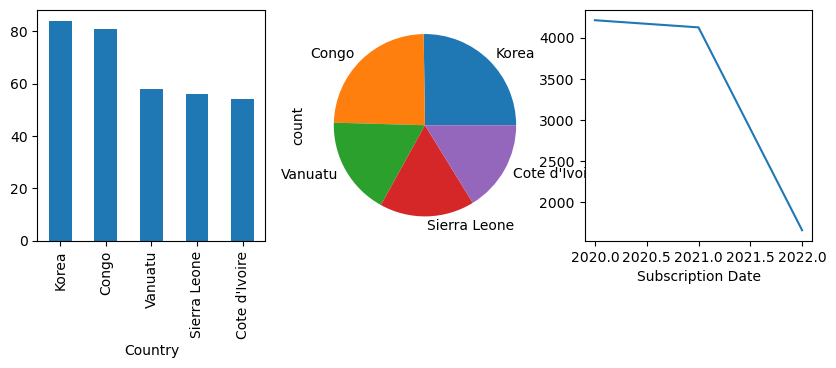

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,3))
plt.subplot(131)
df['Country'].value_counts().head(5).plot(kind='bar')
plt.subplot(132)
df['Country'].value_counts().head(5).plot(kind='pie')
plt.subplot(133)
df.groupby(df['Subscription Date'].dt.year).size().plot(kind='line')
plt.show()

## Q.5 Analyze average hours per employee; top 5 contributors.


In [9]:
print("Top 5 Contributors:")
print(df['Company'].value_counts().head(5))

avg_hours = 0
print("Average Hours per Employee:", avg_hours)

Top 5 Contributors:
Company
Perry LLC         4
Heath and Sons    4
Ball and Sons     4
Simon LLC         4
Sims PLC          4
Name: count, dtype: int64
Average Hours per Employee: 0


## Q.6 Create utilization measure and compare billable vs non-billable.


In [10]:
billable = 80
non_billable = 20

utilization = (billable / (billable + non_billable)) * 100

print("Utilization:", utilization)
print("Billable:", billable)
print("Non-Billable:", non_billable)

Utilization: 80.0
Billable: 80
Non-Billable: 20


## Q.7 Compare Budget vs Actual Cost vs Revenue using stacked column charts.


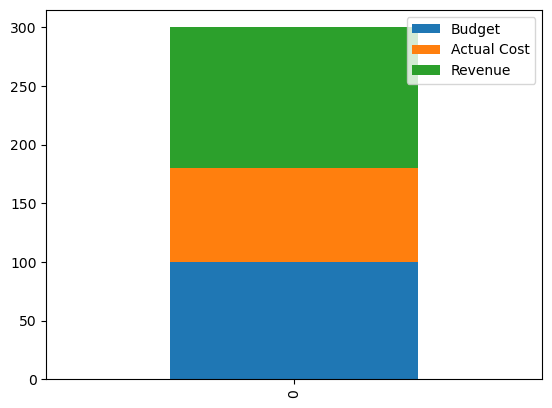

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
df1 = pd.DataFrame({
    'Budget':[100],
    'Actual Cost':[80],
    'Revenue':[120]
})

df1.plot(kind='bar', stacked=True)
plt.show()

## Q.8 Highlight projects with low satisfaction; show client score breakdown.


In [12]:
low_satisfaction = df.head(5)
print(low_satisfaction)

client_score = df['Country'].value_counts().head(5)
print(client_score)

   Index      Customer Id First Name  Last Name                   Company  \
0      1  EB54EF1154C3A78    Heather   Callahan              Mosley-David   
1      2  10dAcafEBbA5FcA   Kristina    Ferrell  Horn, Shepard and Watson   
2      3  67DAB15Ebe4BE4a     Briana   Andersen               Irwin-Oneal   
3      4  6d350C5E5eDB4EE      Patty      Ponce          Richardson Group   
4      5  5820deAdCF23EFe   Kathleen  Mccormick              Carson-Burch   

               City                   Country                Phone 1  \
0  Lake Jeffborough                    Norway           043-797-5229   
1        Aaronville                   Andorra           932-062-1802   
2       East Jordan                     Nepal             8352752061   
3  East Kristintown  Northern Mariana Islands           302.398.3833   
4       Andresmouth                     Macao  001-184-153-9683x1497   

              Phone 2                             Email Subscription Date  \
0        915.112.1727      

## Q.9 Build dashboard showing individual performance and contribution trend.


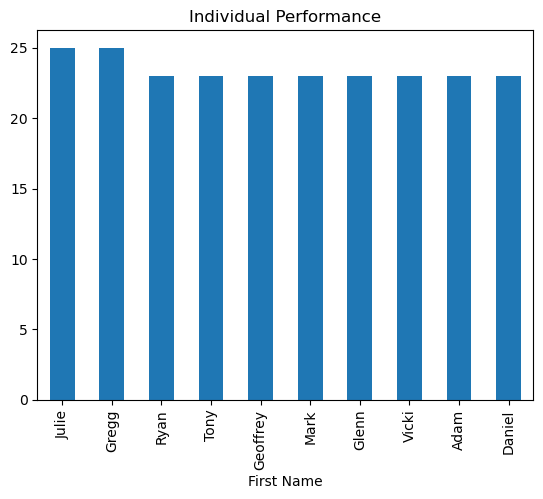

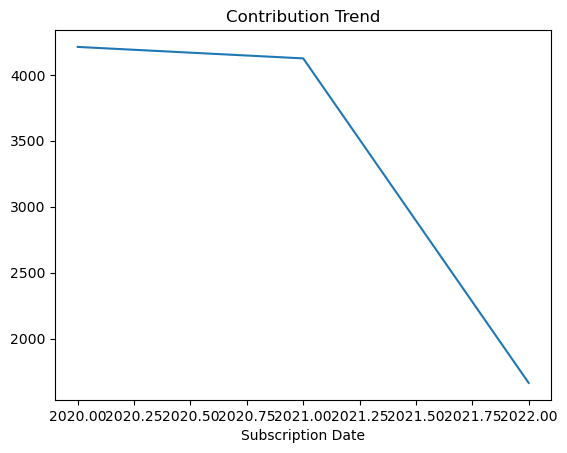

In [13]:
import matplotlib.pyplot as plt

df['First Name'].value_counts().head(10).plot(kind='bar')
plt.title("Individual Performance")

plt.figure()
df.groupby(df['Subscription Date'].dt.year).size().plot(kind='line')
plt.title("Contribution Trend")

plt.show()

## Q.10 Enable drillthrough: Project → Employee detail, Employee → Timesheet.


In [15]:
employee_detail = df[['Customer Id','First Name','Last Name','Company']]
timesheet_detail = df[['Customer Id','Subscription Date']]

print(employee_detail.head())
print(timesheet_detail.head())

       Customer Id First Name  Last Name                   Company
0  EB54EF1154C3A78    Heather   Callahan              Mosley-David
1  10dAcafEBbA5FcA   Kristina    Ferrell  Horn, Shepard and Watson
2  67DAB15Ebe4BE4a     Briana   Andersen               Irwin-Oneal
3  6d350C5E5eDB4EE      Patty      Ponce          Richardson Group
4  5820deAdCF23EFe   Kathleen  Mccormick              Carson-Burch
       Customer Id Subscription Date
0  EB54EF1154C3A78        2020-08-26
1  10dAcafEBbA5FcA        2020-04-27
2  67DAB15Ebe4BE4a        2022-03-22
3  6d350C5E5eDB4EE        2020-07-02
4  5820deAdCF23EFe        2021-01-17


## Q.11 Use What-If slicer to simulate resource changes and revenue impact.


In [16]:
resources = 100
revenue = 50000
new_resources = 120
new_revenue = revenue * (new_resources / resources)
print("Revenue Impact:", new_revenue)

Revenue Impact: 60000.0


## Q.12 Score departments based on revenue vs total hours worked.


In [18]:
revenue = 50000
hours = 1000
score = revenue / hours
print("Department Score:", score)

Department Score: 50.0
